# Public Trasport Accessibility Level (PTAL)  ANALYSIS

This script computes Public Transport Accessibility Level (PTAL) indicators for the Dublin City Council (DCC) area
for two time periods: Morning Peak (08:00–09:00) and Midday Off-Peak (14:00–15:00). The workflow integrates:
(i) walk access times from a pedestrian network Origin–Destination (OD) Cost Matrix, and
(ii) scheduled public transport frequency derived from GTFS stop-level departures.

The script calculates key PTAL components (Scheduled Waiting Time, Average Waiting Time, Total Access Time and
Equivalent Doorstep Frequency) for each origin–stop pair. It then aggregates accessibility to the origin level by
transport mode using the PTAL "best service + ½ of remaining services" rule, and sums across modes to produce the
total PTAL Accessibility Index (AI) for each origin for both time windows. Finally, the results are spatially joined
to a 100 m × 100 m fishnet grid for mapping and exported as a GIS layer. A comparison bar chart summarising PTAL
categories for peak vs off-peak periods is also produced for the results chapter.


In [2]:
#imports the required libraries
import os
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Defines common data path
data_path=r"D:\GIS-TU Dublin\Year_2\THESIS\DCC_Analysis"

In [3]:
#imports the Origin Destination Lines (Output from OD Cost Matrix Solver)
OD_gdf=gpd.read_file(data_path + r'\Data_used\OD_Output\ODLines_PTAL.shp')

In [4]:
#Displays first few rows
OD_gdf.head()

,Name,OriginID,Destinatio,Destinat_1,Total_Leng,Total_Time,Shape_Leng,geometry
0,0 - 8230DB005130,1,2122,1,300.952560,5.011795,0.0,None
1,1 - 8230DB005130,2,2122,1,229.687253,3.823446,0.0,None
2,1 - 8230DB005131,2,2123,2,347.935070,5.797164,0.0,None
3,2 - 8230DB005131,3,2123,1,272.033780,4.526133,0.0,None
4,2 - 8230DB005130,3,2122,2,285.052883,4.745721,0.0,None


In [5]:
#Extracts stop_id
OD_gdf['stop_id']=OD_gdf['Name'].str.split('- ').str[1]
OD_gdf.head()


,Name,OriginID,Destinatio,Destinat_1,Total_Leng,Total_Time,Shape_Leng,geometry,stop_id
0,0 - 8230DB005130,1,2122,1,300.952560,5.011795,0.0,None,8230DB005130
1,1 - 8230DB005130,2,2122,1,229.687253,3.823446,0.0,None,8230DB005130
2,1 - 8230DB005131,2,2123,2,347.935070,5.797164,0.0,None,8230DB005131
3,2 - 8230DB005131,3,2123,1,272.033780,4.526133,0.0,None,8230DB005131
4,2 - 8230DB005130,3,2122,2,285.052883,4.745721,0.0,None,8230DB005130


In [6]:
#Filters the required columns only
OD_clean_gdf = OD_gdf[['Name','OriginID', 'Total_Leng','Total_Time', 'stop_id']]

In [7]:
#Displays first few columns
OD_clean_gdf.head()

,Name,OriginID,Total_Leng,Total_Time,stop_id
0,0 - 8230DB005130,1,300.952560,5.011795,8230DB005130
1,1 - 8230DB005130,2,229.687253,3.823446,8230DB005130
2,1 - 8230DB005131,2,347.935070,5.797164,8230DB005131
3,2 - 8230DB005131,3,272.033780,4.526133,8230DB005131
4,2 - 8230DB005130,3,285.052883,4.745721,8230DB005130


In [8]:
#Reads the stops with frequency values
stops_freq=gpd.read_file(data_path + r'\GTFS_frequency_outputs\all_stops_freq_ITM.shp')

In [9]:
#Filters only required columns
stops_freq_clean=stops_freq[['stop_id','stop_name','route_type', 'freq_MP','freq_OP']]

In [10]:
#Displays first few rows
stops_freq_clean.head()

,stop_id,stop_name,route_type,freq_MP,freq_OP
0,8220000002,Sheriff Street Upper,3,1,0
1,8220000005,Park West Road,3,2,0
2,8220000150,Abbey Street,3,3,3
3,8220000357,George's Quay,3,1,3
4,8220000372,East Wall Road,3,16,2


In [11]:
#Joins OD_Lines with stops and shows first 100 rows
OD_gdf_freq = pd.merge(OD_clean_gdf, stops_freq_clean, on= 'stop_id',how='inner')
OD_gdf_freq.head(100)

,Name,OriginID,Total_Leng,Total_Time,stop_id,stop_name,route_type,freq_MP,freq_OP
0,0 - 8230DB005130,1,300.952560,5.011795,8230DB005130,Charleville Square,3,8,8
1,1 - 8230DB005130,2,229.687253,3.823446,8230DB005130,Charleville Square,3,8,8
2,2 - 8230DB005130,3,285.052883,4.745721,8230DB005130,Charleville Square,3,8,8
3,5 - 8230DB005130,6,304.031602,5.064989,8230DB005130,Charleville Square,3,8,8
4,6 - 8230DB005130,7,304.300025,5.061473,8230DB005130,Charleville Square,3,8,8
...,...,...,...,...,...,...,...,...,...
95,77 - 8230DB001331,78,221.361062,3.686232,8230DB001331,Rathfarnham Castle,3,15,10
96,78 - 8230DB001331,79,255.361911,4.252606,8230DB001331,Rathfarnham Castle,3,15,10
97,79 - 8230DB001331,80,334.307482,5.568349,8230DB001331,Rathfarnham Castle,3,15,10
98,100 - 8230DB001331,101,292.360000,4.870415,8230DB001331,Rathfarnham Castle,3,15,10


In [12]:
# Check whether peak and off-peak service frequencies are identical for all records
(OD_gdf_freq['freq_MP'] == OD_gdf_freq['freq_OP']).all()

False

In [13]:
# Count how many stops have identical vs different service frequencies between peak and off-peak periods
(stops_freq_clean['freq_MP'] == stops_freq_clean['freq_OP']).value_counts()

False    1556
True      638
dtype: int64

In [14]:
#Make a copy of dataframe
df = OD_gdf_freq.copy()

In [15]:
# Calculate Public Transport Accessibility metrics for  Morning Peak (MP) and Off-Peak (OP) periods
# MP
df["time_interval_MP"] = 60.0
headway_mp = df["time_interval_MP"] / df["freq_MP"].replace(0, np.nan)
df["SWT_MP"] = 0.5 * headway_mp
df["AWT_MP"] = df["SWT_MP"] + df["route_type"].apply(lambda x: 2.0 if x == 3 else 0.75)
df["TAT_MP"] = df["Total_Time"] + df["AWT_MP"]       # walk + wait
df["EDF_MP"] = (30.0 / df["TAT_MP"].replace(0, np.nan)).fillna(0.0)

# OP
df["time_interval_OP"] = 60.0
headway_op = df["time_interval_OP"] / df["freq_OP"].replace(0, np.nan)
df["SWT_OP"] = 0.5 * headway_op
df["AWT_OP"] = df["SWT_OP"] + df["route_type"].apply(lambda x: 2.0 if x == 3 else 0.75)
df["TAT_OP"] = df["Total_Time"] + df["AWT_OP"]
df["EDF_OP"] = (30.0 / df["TAT_OP"].replace(0, np.nan)).fillna(0.0)

In [16]:
# helper to compute AI_mode from a series of EDFs
def ai_mode(s: pd.Series) -> float:
    if s.empty:
        return 0.0
    best = s.max()
    others = s.sum() - best
    return float(best + 0.5 * others)

# Per (OriginID, route_type)
AI_MP = (df.groupby(["OriginID", "route_type"])["EDF_MP"]
           .apply(ai_mode).reset_index(name="AI_MP"))
AI_OP = (df.groupby(["OriginID", "route_type"])["EDF_OP"]
           .apply(ai_mode).reset_index(name="AI_OP"))

# Per-Origin totals (sum across modes)
AI_total_MP = (AI_MP.groupby("OriginID", as_index=False)["AI_MP"]
                  .sum().rename(columns={"AI_MP": "AI_total_MP"}))
AI_total_OP = (AI_OP.groupby("OriginID", as_index=False)["AI_OP"]
                  .sum().rename(columns={"AI_OP": "AI_total_OP"}))

#Merge totals ONLY
df = (df.merge(AI_total_MP, on="OriginID", how="left")
        .merge(AI_total_OP, on="OriginID", how="left"))

# Extract unique accessibility values per origin by removing duplicate records
per_origin = df[["OriginID","AI_total_MP","AI_total_OP"]].drop_duplicates().reset_index(drop=True)

In [17]:
#Displays first few rows 
df.head()

,Name,OriginID,Total_Leng,Total_Time,stop_id,stop_name,route_type,freq_MP,freq_OP,time_interval_MP,SWT_MP,AWT_MP,TAT_MP,EDF_MP,time_interval_OP,SWT_OP,AWT_OP,TAT_OP,EDF_OP,AI_total_MP,AI_total_OP
0,0 - 8230DB005130,1,300.952560,5.011795,8230DB005130,Charleville Square,3,8,8,60.0,3.75,5.75,10.761795,2.787639,60.0,3.75,5.75,10.761795,2.787639,2.787639,2.787639
1,1 - 8230DB005130,2,229.687253,3.823446,8230DB005130,Charleville Square,3,8,8,60.0,3.75,5.75,9.573446,3.133668,60.0,3.75,5.75,9.573446,3.133668,4.558922,4.432688
2,2 - 8230DB005130,3,285.052883,4.745721,8230DB005130,Charleville Square,3,8,8,60.0,3.75,5.75,10.495721,2.858308,60.0,3.75,5.75,10.495721,2.858308,4.671203,4.348540
3,5 - 8230DB005130,6,304.031602,5.064989,8230DB005130,Charleville Square,3,8,8,60.0,3.75,5.75,10.814989,2.773928,60.0,3.75,5.75,10.814989,2.773928,2.773928,2.773928
4,6 - 8230DB005130,7,304.300025,5.061473,8230DB005130,Charleville Square,3,8,8,60.0,3.75,5.75,10.811473,2.774830,60.0,3.75,5.75,10.811473,2.774830,2.774830,2.774830


In [18]:
# Identify the maximum values for each numeric variable in the dataset
df.max()

Name                9999 - 8220DB001495
OriginID                          16405
Total_Leng                   401.776237
Total_Time                      6.66989
stop_id                      8250IR0039
stop_name            Éamonn Ceannt Park
route_type                            3
freq_MP                              80
freq_OP                              50
time_interval_MP                   60.0
SWT_MP                             30.0
AWT_MP                             32.0
TAT_MP                        38.669668
EDF_MP                        16.753333
time_interval_OP                   60.0
SWT_OP                             30.0
AWT_OP                             32.0
TAT_OP                        38.669668
EDF_OP                        15.494723
AI_total_MP                  109.875146
AI_total_OP                   99.722835
dtype: object

In [19]:
# Compute the minimum and maximum values of accessibility indices for peak and off-peak periods
df[['AI_total_MP', 'AI_total_OP']].agg(['min', 'max'])

,AI_total_MP,AI_total_OP
min,0.000000,0.000000
max,109.875146,99.722835


In [20]:
#Reads 100*100 Fishnet grid
fishnet_gdf=gpd.read_file(data_path + r'\Data_used\DCC\Grid_100_SA.shp')


In [21]:
#Displays first few rows 
fishnet_gdf.head()

,Id,geometry
0,0,"POLYGON ((713810.423 728481.740, 713810.423 72..."
1,0,"POLYGON ((713610.423 728581.740, 713610.423 72..."
2,0,"POLYGON ((713710.423 728581.740, 713710.423 72..."
3,0,"POLYGON ((713810.423 728581.740, 713810.423 72..."
4,0,"POLYGON ((713910.423 728581.740, 713910.423 72..."


In [22]:
#Reads Fishnet Grid Labels
fishnet_gdf_Point=gpd.read_file(data_path + r'\Data_used\DCC\Grid_100_label_SA.shp')

In [23]:
#Displays first few rows
fishnet_gdf_Point.head()

,Id,geometry
0,0,POINT (713660.423 728531.740)
1,0,POINT (713760.423 728531.740)
2,0,POINT (713860.423 728531.740)
3,0,POINT (713960.423 728531.740)
4,0,POINT (714060.423 728531.740)


In [24]:
# Add an OriginID column to fishnet_gdf_Point matching OD_Lines
fishnet_gdf_Point = fishnet_gdf_Point.reset_index().rename(columns={"index":"OriginID"})


In [25]:
#Displays first few rows
fishnet_gdf_Point.head()

,OriginID,Id,geometry
0,0,0,POINT (713660.423 728531.740)
1,1,0,POINT (713760.423 728531.740)
2,2,0,POINT (713860.423 728531.740)
3,3,0,POINT (713960.423 728531.740)
4,4,0,POINT (714060.423 728531.740)


In [26]:
#Merge Accessibility Index (AI) with 100*100 fishnet grid centroids
fishnet_points__with_AI = fishnet_gdf_Point.merge(df, on='OriginID', how='right')

In [27]:
#Displays first few rows
fishnet_points__with_AI.head()

,OriginID,Id,geometry,Name,Total_Leng,Total_Time,stop_id,stop_name,route_type,freq_MP,freq_OP,time_interval_MP,SWT_MP,AWT_MP,TAT_MP,EDF_MP,time_interval_OP,SWT_OP,AWT_OP,TAT_OP,EDF_OP,AI_total_MP,AI_total_OP
0,1,0,POINT (713760.423 728531.740),0 - 8230DB005130,300.952560,5.011795,8230DB005130,Charleville Square,3,8,8,60.0,3.75,5.75,10.761795,2.787639,60.0,3.75,5.75,10.761795,2.787639,2.787639,2.787639
1,2,0,POINT (713860.423 728531.740),1 - 8230DB005130,229.687253,3.823446,8230DB005130,Charleville Square,3,8,8,60.0,3.75,5.75,9.573446,3.133668,60.0,3.75,5.75,9.573446,3.133668,4.558922,4.432688
2,3,0,POINT (713960.423 728531.740),2 - 8230DB005130,285.052883,4.745721,8230DB005130,Charleville Square,3,8,8,60.0,3.75,5.75,10.495721,2.858308,60.0,3.75,5.75,10.495721,2.858308,4.671203,4.348540
3,6,0,POINT (713660.423 728631.740),5 - 8230DB005130,304.031602,5.064989,8230DB005130,Charleville Square,3,8,8,60.0,3.75,5.75,10.814989,2.773928,60.0,3.75,5.75,10.814989,2.773928,2.773928,2.773928
4,7,0,POINT (713760.423 728631.740),6 - 8230DB005130,304.300025,5.061473,8230DB005130,Charleville Square,3,8,8,60.0,3.75,5.75,10.811473,2.774830,60.0,3.75,5.75,10.811473,2.774830,2.774830,2.774830


In [28]:
#Spatially joins AI with fishnet grid
fishnet_with_AI = gpd.sjoin(fishnet_gdf, fishnet_points__with_AI[['OriginID', 'AI_total_MP','AI_total_OP','geometry']], 
                            how='inner', predicate='contains')

fishnet_with_AI.head()


,Id,geometry,index_right,OriginID,AI_total_MP,AI_total_OP
0,0,"POLYGON ((713810.423 728481.740, 713810.423 72...",17,2,4.558922,4.432688
0,0,"POLYGON ((713810.423 728481.740, 713810.423 72...",1,2,4.558922,4.432688
1,0,"POLYGON ((713610.423 728581.740, 713610.423 72...",3,6,2.773928,2.773928
2,0,"POLYGON ((713710.423 728581.740, 713710.423 72...",4,7,2.774830,2.774830
3,0,"POLYGON ((713810.423 728581.740, 713810.423 72...",5,8,5.482035,5.307062


In [29]:
#Saves PTAL shapefile.
fishnet_with_AI.to_file(data_path + r"\Data_Extracted\PTAL\PTALs.shp", driver="ESRI Shapefile")

[29]:2: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.


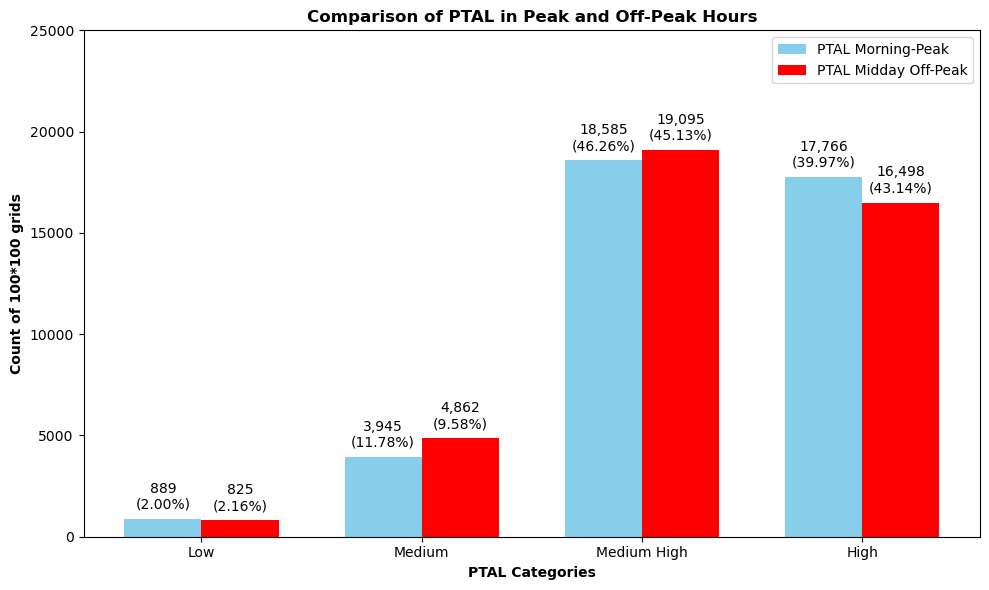

In [306]:
# PTAL comparision Bar-chart
categories = ['Low','Medium', 'Medium High', 'High']
count_OP = [825, 4862, 19095, 16498]
count_MP = [889, 3945, 18585, 17766]

# Calculate total counts for percentage calculation
total_OP = sum(count_OP)
total_MP = sum(count_MP)

# Calculate percentages
percent_OP = [(c / total_OP) * 100 for c in count_OP]
percent_MP = [(c / total_MP) * 100 for c in count_MP]

# Bar chart setup
x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, count_MP, width, label='PTAL Morning-Peak', color='skyblue')
rects2 = ax.bar(x + width/2, count_OP, width, label='PTAL Midday Off-Peak', color='red')

# Labels and title
ax.set_xlabel('PTAL Categories', fontweight='bold')
ax.set_ylabel('Count of 100*100 grids', fontweight='bold')
ax.set_title('Comparison of PTAL in Peak and Off-Peak Hours', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()

# Annotate bars with count and percentage
def autolabel(rects, percentages):
    for rect, pct in zip(rects, percentages):
        height = rect.get_height()
        ax.annotate(f'{height:,}\n({pct:.2f}%)',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5),
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1, percent_OP)
autolabel(rects2, percent_MP)

# Adjust y-axis to fit labels
ax.set_ylim(0, 25000)

fig.tight_layout()
# Save as PNG
fig.savefig(r"D:\GIS-TU Dublin\Year_2\THESIS\REPORT\Maps\new_maps\PTAL_comparison.png", dpi=300)
plt.show()
